In [3]:

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard2/train.csv"
test_filepath  = "my_data/standard2/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_means = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_means[i] = np.mean(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, means, stds):
    # features [...1344]
    # means & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - means) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks

def evaluate(disable_feature_idx=None):
    i = 0
    accuracy_struct = []
    for X,y in zip(train_X, train_y):
        if disable_feature_idx is not None: X[disable_feature_idx] = X[disable_feature_idx] * 0
        zscores = get_zscores(X, train_means, train_std)
        zscores = abs_zscores(zscores)
        labels_scores = get_labels_scores(zscores)
        pred_labels = get_pred_labels(labels_scores)
        accuracy_struct.append(is_accurate(pred_labels, y))
        print(f"{disable_feature_idx} --- {i}/{len(train_X)-1}", end="\r"); i+=1
    print()
    acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
    for acc in accuracy_struct:
        is_acc, order = acc
        if is_acc: acc_totals[order] +=1

    return np.array(acc_totals) / len(train_X) * 100

orig_acc = evaluate()
print("original: ", orig_acc)
all_acc_totals = []
for disable_feature_idx in range(int(num_features/8)):
    all_acc_totals.append(evaluate(disable_feature_idx))
    


Train samples: 12915
Features     : 1536
Labels       : [0 1 2 3 4 5 6 7 8]
None --- 12914/12914
original:  [6.72551297e+01 1.72822300e+01 6.89121177e+00 4.46767325e+00
 9.67866822e-01 6.19434766e-01 1.75764615e+00 7.43321719e-01
 1.54858691e-02]
0 --- 12914/12914
1 --- 12914/12914
2 --- 12914/12914
3 --- 12914/12914
4 --- 12914/12914
5 --- 12914/12914
6 --- 12914/12914
7 --- 12914/12914
8 --- 12914/12914
9 --- 12914/12914
10 --- 12914/12914
11 --- 12914/12914
12 --- 12914/12914
13 --- 12914/12914
14 --- 12914/12914
15 --- 12914/12914
16 --- 12914/12914
17 --- 12914/12914
18 --- 12914/12914
19 --- 12914/12914
20 --- 12914/12914
21 --- 12914/12914
22 --- 12914/12914
23 --- 12914/12914
24 --- 12914/12914
25 --- 12914/12914
26 --- 12914/12914
27 --- 12914/12914
28 --- 12914/12914
29 --- 12914/12914
30 --- 12914/12914
31 --- 12914/12914
32 --- 12914/12914
33 --- 12914/12914
34 --- 12914/12914
35 --- 12914/12914
36 --- 12914/12914
37 --- 12914/12914
38 --- 12914/12914
39 --- 12914/12914
40 

/tmp/ipykernel_81118/696682033.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


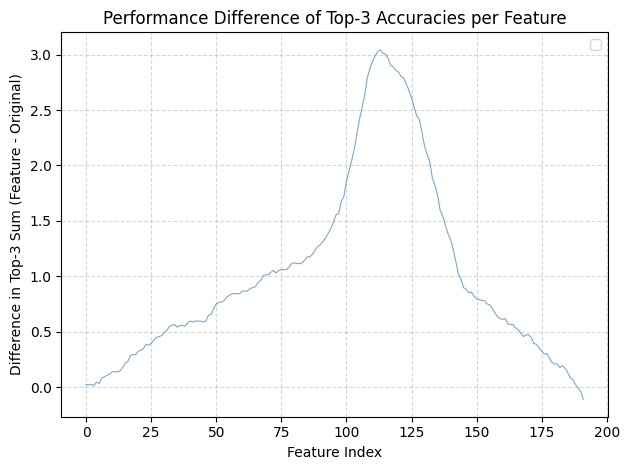

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Original baseline accuracies

orig_top3_sum = np.sum(orig_acc[:3])
all_acc_totals = np.array(all_acc_totals)
y_values = np.sum(all_acc_totals[:, :3] - orig_acc[:3], axis=1)
x_values = np.arange(len(all_acc_totals))

# Visualization
plt.plot(x_values, y_values, color='steelblue', alpha=0.7, linewidth=0.8)
plt.xlabel('Feature Index')
plt.ylabel('Difference in Top-3 Sum (Feature - Original)')
plt.title('Performance Difference of Top-3 Accuracies per Feature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#Positive values indicate that I am more accurate without this features





In [7]:
#good features: removing them causes the accuracy to decrease (original - new) = positive (more positive is a better feature
#bad features: removign them cuase the accuracy to increase (original - new) = negetive (more negetive are worst featrue)

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard2/train.csv"
test_filepath  = "my_data/standard2/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_means = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_means[i] = np.mean(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, means, stds):
    # features [...1344]
    # means & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - means) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks

def evaluate(disable_feature_idx=None):
    i = 0
    accuracy_struct = []
    for X,y in zip(train_X, train_y):
        if disable_feature_idx is not None: X[disable_feature_idx] = X[disable_feature_idx] * 0
        zscores = get_zscores(X, train_means, train_std)
        zscores = abs_zscores(zscores)
        labels_scores = get_labels_scores(zscores)
        pred_labels = get_pred_labels(labels_scores)
        accuracy_struct.append(is_accurate(pred_labels, y))
        if disable_feature_idx % 5 == 0: print(f"{disable_feature_idx} --- {i}/{len(train_X)-1}", end="\r"); i+=1
    print()
    acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
    for acc in accuracy_struct:
        is_acc, order = acc
        if is_acc: acc_totals[order] +=1

    return np.array(acc_totals) / len(train_X) * 100

orig_acc = evaluate()
print("original: ", orig_acc)
all_acc_totals = []
for disable_feature_idx in range(int(num_features)):
    all_acc_totals.append(evaluate(disable_feature_idx))

    

Train samples: 12915
Features     : 1536
Labels       : [0 1 2 3 4 5 6 7 8]
None --- 0/12914
original:  [6.72551297e+01 1.72822300e+01 6.89121177e+00 4.46767325e+00
 9.67866822e-01 6.19434766e-01 1.75764615e+00 7.43321719e-01
 1.54858691e-02]
0 --- 0/12914
1 --- 0/12914
2 --- 0/12914
3 --- 0/12914
4 --- 0/12914
5 --- 0/12914
6 --- 0/12914
7 --- 0/12914
8 --- 0/12914
9 --- 0/12914
10 --- 0/12914
11 --- 0/12914
12 --- 0/12914
13 --- 0/12914
14 --- 0/12914
15 --- 0/12914
16 --- 0/12914
17 --- 0/12914
18 --- 0/12914
19 --- 0/12914
20 --- 0/12914
21 --- 0/12914
22 --- 0/12914
23 --- 0/12914
24 --- 0/12914
25 --- 0/12914
26 --- 0/12914
27 --- 0/12914
28 --- 0/12914
29 --- 0/12914
30 --- 0/12914
31 --- 0/12914
32 --- 0/12914
33 --- 0/12914
34 --- 0/12914
35 --- 0/12914
36 --- 0/12914
37 --- 0/12914
38 --- 0/12914
39 --- 0/12914
40 --- 0/12914
41 --- 0/12914
42 --- 0/12914
43 --- 0/12914
44 --- 0/12914
45 --- 0/12914
46 --- 0/12914
47 --- 0/12914
48 --- 0/12914
49 --- 0/12914
50 --- 0/12914
51

/tmp/ipykernel_81118/1158965448.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


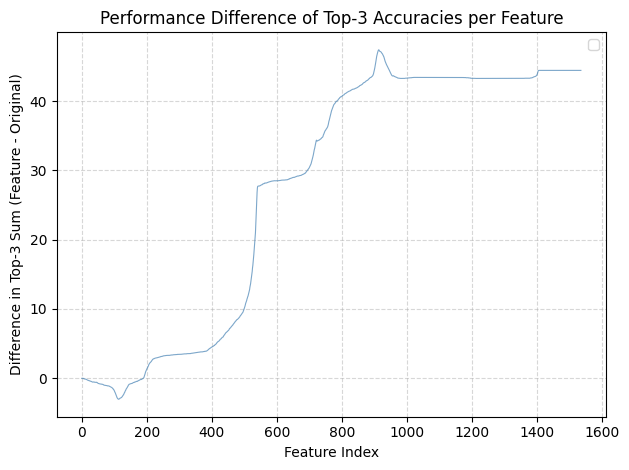

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Original baseline accuracies


## I WILL NEED TO RERUN THIS

orig_top3_sum = np.sum(orig_acc[:3])
all_acc_totals = np.array(all_acc_totals)
y_values = np.sum(orig_acc[:3] - all_acc_totals[:, :3], axis=1)
x_values = np.arange(len(all_acc_totals))

# Visualization
plt.plot(x_values, y_values, color='steelblue', alpha=0.7, linewidth=0.8)
plt.xlabel('Feature Index')
plt.ylabel('Difference in Top-3 Sum (Feature - Original)')
plt.title('Performance Difference of Top-3 Accuracies per Feature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#Positive values indicate that I am more accurate without this features


In [15]:
orig_top3 = np.sum(orig_acc[:3])
feat_top3 = np.sum(all_acc_totals[:, :3], axis=1)

neg_mask = feat_top3 > orig_top3
neg_values = feat_top3[neg_mask]

neg_indices = np.where(neg_mask)[0]

for i in neg_indices:
    print(f"Feature {i}: {feat_top3[i]:.3f} > {orig_top3:.3f}")

Feature 0: 91.452 > 91.429
Feature 1: 91.452 > 91.429
Feature 2: 91.452 > 91.429
Feature 3: 91.444 > 91.429
Feature 4: 91.475 > 91.429
Feature 5: 91.460 > 91.429
Feature 6: 91.514 > 91.429
Feature 7: 91.521 > 91.429
Feature 8: 91.537 > 91.429
Feature 9: 91.545 > 91.429
Feature 10: 91.568 > 91.429
Feature 11: 91.568 > 91.429
Feature 12: 91.568 > 91.429
Feature 13: 91.576 > 91.429
Feature 14: 91.607 > 91.429
Feature 15: 91.645 > 91.429
Feature 16: 91.661 > 91.429
Feature 17: 91.715 > 91.429
Feature 18: 91.723 > 91.429
Feature 19: 91.723 > 91.429
Feature 20: 91.754 > 91.429
Feature 21: 91.762 > 91.429
Feature 22: 91.777 > 91.429
Feature 23: 91.816 > 91.429
Feature 24: 91.808 > 91.429
Feature 25: 91.823 > 91.429
Feature 26: 91.854 > 91.429
Feature 27: 91.878 > 91.429
Feature 28: 91.885 > 91.429
Feature 29: 91.893 > 91.429
Feature 30: 91.924 > 91.429
Feature 31: 91.940 > 91.429
Feature 32: 91.978 > 91.429
Feature 33: 91.986 > 91.429
Feature 34: 91.994 > 91.429
Feature 35: 91.971 > 91.429
Fe

Train samples: 12915
Test samples : 3296
Features     : 1280
Labels       : [0 1 2 3 4 5 6 7 8]
0 Pred: [8 2 7 6 1 5 4 0 3], Label: 8, (True, 0)
10 Pred: [0 4 3 6 1 5 2 7 8], Label: 3, (True, 2)
20 Pred: [5 6 4 1 0 2 3 7 8], Label: 5, (True, 0)
30 Pred: [2 1 6 7 5 4 0 8 3], Label: 7, (True, 3)
40 Pred: [0 4 3 1 6 5 2 7 8], Label: 0, (True, 0)
50 Pred: [5 6 1 4 3 2 0 7 8], Label: 5, (True, 0)
60 Pred: [0 4 3 6 1 5 2 7 8], Label: 0, (True, 0)
70 Pred: [0 4 3 6 1 5 2 7 8], Label: 0, (True, 0)
80 Pred: [5 6 4 1 0 3 2 7 8], Label: 5, (True, 0)
90 Pred: [0 4 6 5 1 3 2 7 8], Label: 0, (True, 0)
100 Pred: [8 2 7 6 1 5 4 0 3], Label: 2, (True, 1)
110 Pred: [2 1 6 7 8 5 4 0 3], Label: 2, (True, 0)
120 Pred: [2 1 6 8 7 5 4 0 3], Label: 2, (True, 0)
130 Pred: [1 2 6 4 5 0 3 7 8], Label: 1, (True, 0)
140 Pred: [2 1 7 6 5 4 8 0 3], Label: 2, (True, 0)
150 Pred: [0 4 3 6 1 5 2 7 8], Label: 0, (True, 0)
160 Pred: [1 2 4 6 0 5 3 7 8], Label: 2, (True, 1)
170 Pred: [2 1 6 5 7 4 8 0 3], Label: 2, (True, 

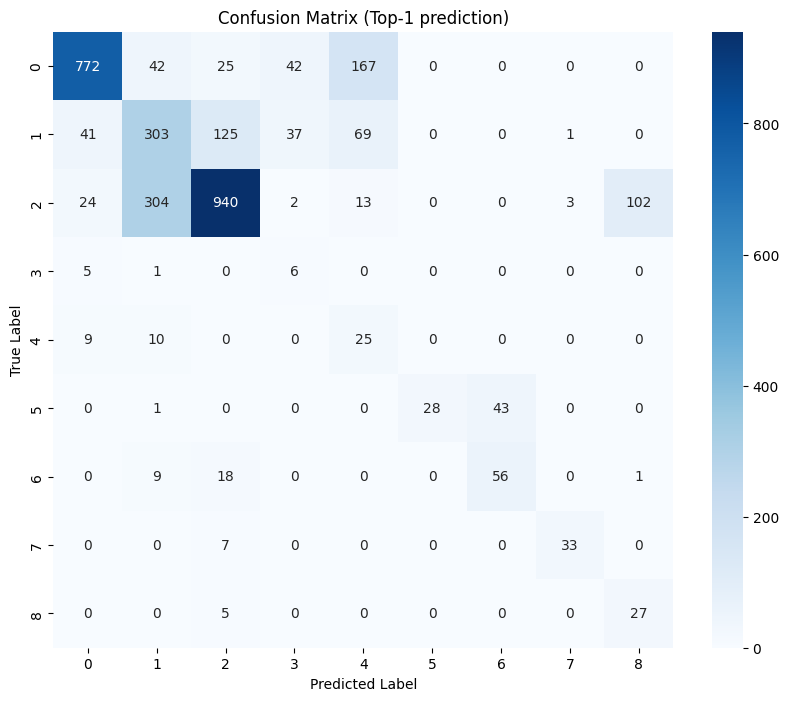

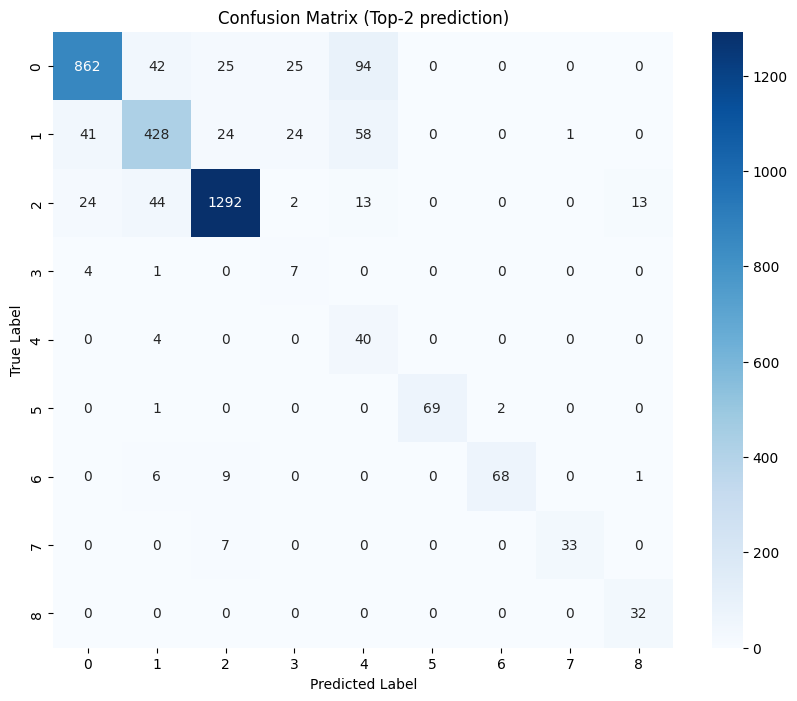

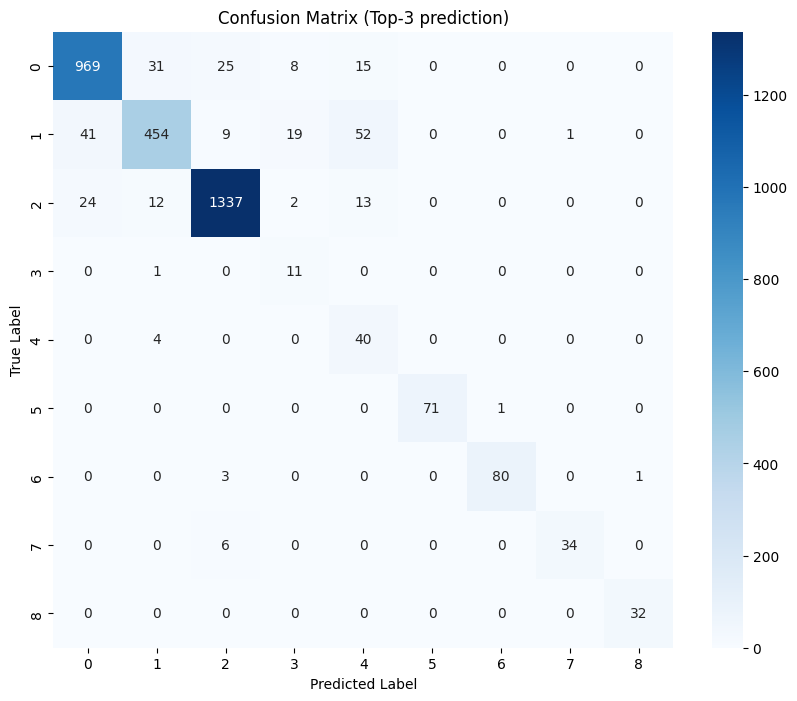

In [16]:
## using different data

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/standard3/train.csv"
test_filepath  = "my_data/standard3/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)
test_X,  test_y  = test_data[:, :-1],  test_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Test samples : {len(test_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_means = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_means[i] = np.mean(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, means, stds):
    # features [...1344]
    # means & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - means) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks
    
all_pred_labels = []
accuracy_struct = []
for i in range(len(test_y)):
    zscores = get_zscores(test_X[i], train_means, train_std)
    zscores = abs_zscores(zscores)
    labels_scores = get_labels_scores(zscores)
    pred_labels = get_pred_labels(labels_scores)
    all_pred_labels.append(pred_labels)
    accuracy_struct.append(is_accurate(pred_labels, test_y[i]))
    if i % 10 == 0: print(f"{i} Pred: {pred_labels}, Label: {test_y[i]}, {is_accurate(pred_labels, test_y[i])}")

# showcase the outputs for this. show a confusion matrix with all (True, 0) and show a confusion matrix with all (True,0) and (True, 1) 

acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
for acc in accuracy_struct:
    is_acc, order = acc
    if is_acc: acc_totals[order] +=1

print(np.array(acc_totals) / len(test_y) * 100) 


import matplotlib.pyplot as plt
import seaborn as sns

#I apologize

# Initialize confusion matrices
conf_mat_top1 = np.zeros((num_labels, num_labels), dtype=int)  # only top-1 prediction
conf_mat_top2 = np.zeros((num_labels, num_labels), dtype=int)  # top-1 or top-2 prediction
conf_mat_top3 = np.zeros((num_labels, num_labels), dtype=int)  # top-1, top-2, or top-3 prediction

for i, (pred_labels, (is_acc, order)) in enumerate(zip(all_pred_labels, accuracy_struct)):
    true_label = test_y[i]
    true_idx = np.where(labels == true_label)[0][0]

    pred_label_top1 = pred_labels[0]
    pred_idx_top1 = np.where(labels == pred_label_top1)[0][0]
    conf_mat_top1[true_idx, pred_idx_top1] += 1

    # Top-2 confusion matrix
    if is_acc and order <= 1:
        pred_label_top2 = pred_labels[order]
        pred_idx_top2 = np.where(labels == pred_label_top2)[0][0]
        conf_mat_top2[true_idx, pred_idx_top2] += 1
    else:
        conf_mat_top2[true_idx, pred_idx_top1] += 1

    # Top-3 confusion matrix
    if is_acc and order <= 2:
        pred_label_top3 = pred_labels[order]
        pred_idx_top3 = np.where(labels == pred_label_top3)[0][0]
        conf_mat_top3[true_idx, pred_idx_top3] += 1
    else:
        conf_mat_top3[true_idx, pred_idx_top1] += 1


# Plot confusion matrices nicely
def plot_confusion_matrix(conf_mat, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_mat_top1, "Confusion Matrix (Top-1 prediction)")
plot_confusion_matrix(conf_mat_top2, "Confusion Matrix (Top-2 prediction)")
plot_confusion_matrix(conf_mat_top3, "Confusion Matrix (Top-3 prediction)")

Train samples: 12915
Test samples : 3296
Features     : 4096
Labels       : [0 1 2 3 4 5 6 7 8]
0 Pred: [8 2 7 6 1 5 4 0 3], Label: 8, (True, 0)
10 Pred: [0 4 3 6 5 1 2 7 8], Label: 3, (True, 2)
20 Pred: [6 5 4 1 0 2 3 7 8], Label: 5, (True, 1)
30 Pred: [2 1 6 7 5 4 8 0 3], Label: 7, (True, 3)
40 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
50 Pred: [6 5 4 0 1 2 3 7 8], Label: 5, (True, 1)
60 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
70 Pred: [0 4 6 3 5 1 2 7 8], Label: 0, (True, 0)
80 Pred: [5 6 4 1 0 3 2 7 8], Label: 5, (True, 0)
90 Pred: [0 6 4 5 1 3 2 7 8], Label: 0, (True, 0)
100 Pred: [8 7 2 6 1 5 4 0 3], Label: 2, (True, 2)
110 Pred: [2 1 6 7 5 8 4 0 3], Label: 2, (True, 0)
120 Pred: [2 1 6 8 7 5 4 0 3], Label: 2, (True, 0)
130 Pred: [1 2 6 4 5 0 3 7 8], Label: 1, (True, 0)
140 Pred: [2 1 7 6 5 8 4 0 3], Label: 2, (True, 0)
150 Pred: [0 4 3 6 5 1 2 7 8], Label: 0, (True, 0)
160 Pred: [1 2 4 6 5 0 3 7 8], Label: 2, (True, 1)
170 Pred: [2 1 6 5 7 4 8 0 3], Label: 2, (True, 

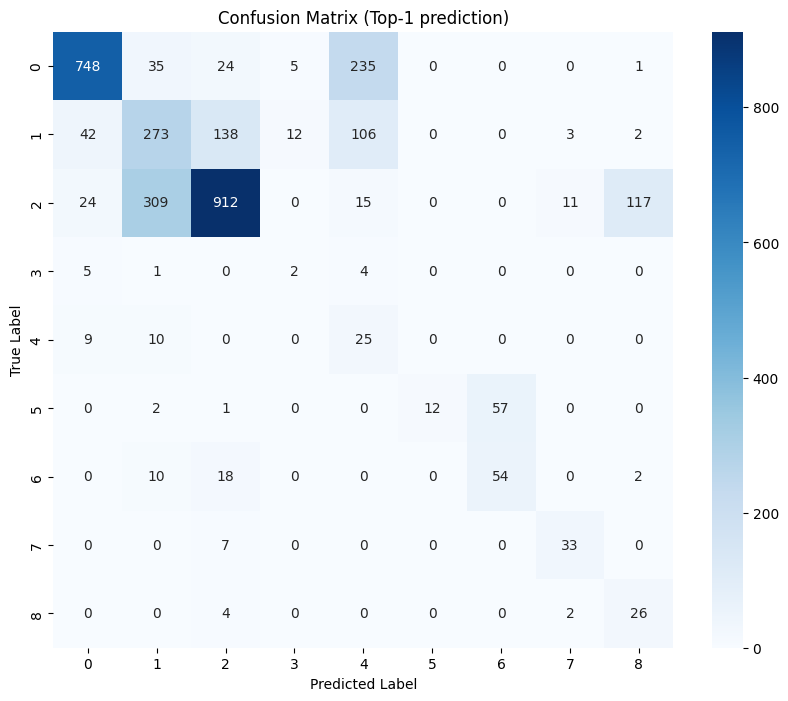

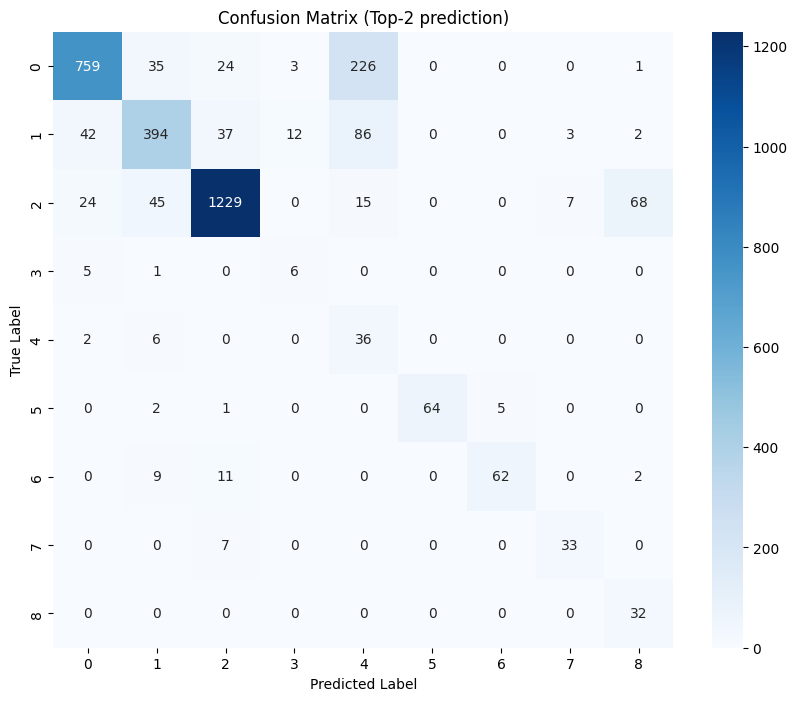

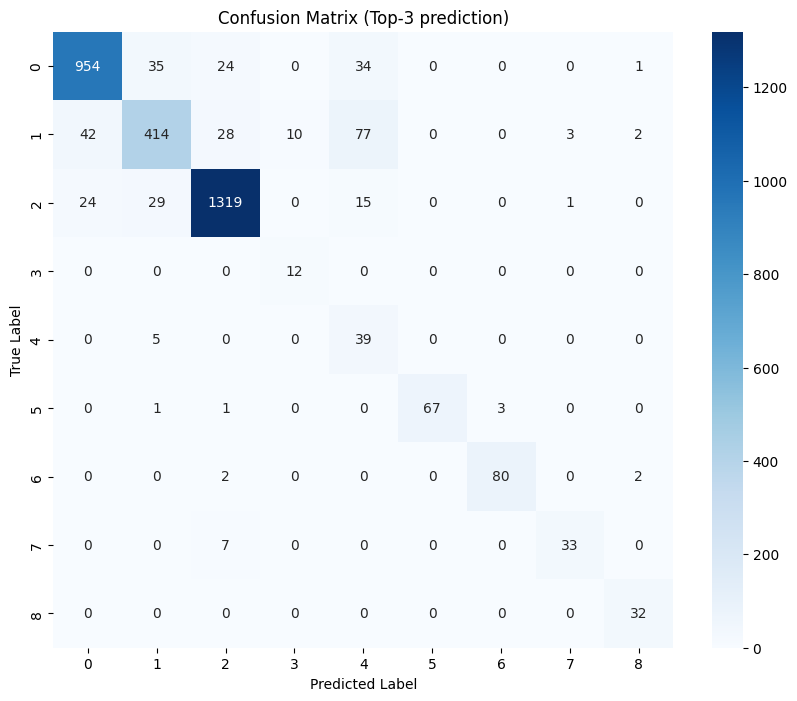

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
KeyboardInterrupt


In [17]:
## using different data

import numpy as np

labels = np.array([0,1,2,3,4,5,6,7,8])
train_filepath = "my_data/full64x64specto/train.csv"
test_filepath  = "my_data/full64x64specto/test.csv"
EPS = 1e-8

train_data = np.loadtxt(train_filepath, delimiter=",", skiprows=1)
test_data  = np.loadtxt(test_filepath,  delimiter=",", skiprows=1)

train_X, train_y = train_data[:, :-1], train_data[:, -1].astype(int)
test_X,  test_y  = test_data[:, :-1],  test_data[:, -1].astype(int)

num_labels = len(labels)
num_features = train_X.shape[1]

print(f"Train samples: {len(train_X)}")
print(f"Test samples : {len(test_X)}")
print(f"Features     : {num_features}")
print(f"Labels       : {labels}")

train_means = np.zeros((num_labels, num_features))
train_std     = np.zeros((num_labels, num_features))

for i, lbl in enumerate(labels):
    X_lbl = train_X[train_y == lbl]

    train_means[i] = np.mean(X_lbl, axis=0)
    train_std[i]     = np.std(X_lbl, axis=0, ddof=1)

# Avoid divide-by-zero
train_std[train_std < EPS] = EPS

def get_zscores(features, means, stds):
    # features [...1344]
    # means & stds [[...1344], ...9]
    # returns: zscores [[...1344], ...9]
    return (features - means) / stds

def abs_zscores(zscores):
    # zscore [[...1344], ...9]
    return abs(zscores)

def get_labels_scores(zscores):
    # zscore [[...1344], ...9]
    # returns: labels_scores [...9]
    # Note: lower score is better (means closer to model)
    R = 1
    return np.sum(zscores, axis=R)

def get_pred_labels(labels_scores):
    # labels_score [...9]
    # returns: pred_labels [...9] of labels with label at spot 0 being the smallest label score, and so on
    pred_label_indices = np.argsort(labels_scores)
    pred_labels = labels[pred_label_indices]
    return pred_labels

def is_accurate(pred_labels, label, max_checks=len(labels)):
    # pred_labels [...9]
    # label int
    # max_trys int
    # check if pre_label at idx=0 matches label, if not and max_trys allows it, try again, ...
    for check in range(max_checks):
        if pred_labels[check] == label: return True, check
    return False, max_checks
    
all_pred_labels = []
accuracy_struct = []
for i in range(len(test_y)):
    zscores = get_zscores(test_X[i], train_means, train_std)
    zscores = abs_zscores(zscores)
    labels_scores = get_labels_scores(zscores)
    pred_labels = get_pred_labels(labels_scores)
    all_pred_labels.append(pred_labels)
    accuracy_struct.append(is_accurate(pred_labels, test_y[i]))
    if i % 10 == 0: print(f"{i} Pred: {pred_labels}, Label: {test_y[i]}, {is_accurate(pred_labels, test_y[i])}")

# showcase the outputs for this. show a confusion matrix with all (True, 0) and show a confusion matrix with all (True,0) and (True, 1) 

acc_totals = [0, 0, 0, 0, 0, 0, 0, 0, 0]
for acc in accuracy_struct:
    is_acc, order = acc
    if is_acc: acc_totals[order] +=1

print(np.array(acc_totals) / len(test_y) * 100) 


import matplotlib.pyplot as plt
import seaborn as sns

#I apologize

# Initialize confusion matrices
conf_mat_top1 = np.zeros((num_labels, num_labels), dtype=int)  # only top-1 prediction
conf_mat_top2 = np.zeros((num_labels, num_labels), dtype=int)  # top-1 or top-2 prediction
conf_mat_top3 = np.zeros((num_labels, num_labels), dtype=int)  # top-1, top-2, or top-3 prediction

for i, (pred_labels, (is_acc, order)) in enumerate(zip(all_pred_labels, accuracy_struct)):
    true_label = test_y[i]
    true_idx = np.where(labels == true_label)[0][0]

    pred_label_top1 = pred_labels[0]
    pred_idx_top1 = np.where(labels == pred_label_top1)[0][0]
    conf_mat_top1[true_idx, pred_idx_top1] += 1

    # Top-2 confusion matrix
    if is_acc and order <= 1:
        pred_label_top2 = pred_labels[order]
        pred_idx_top2 = np.where(labels == pred_label_top2)[0][0]
        conf_mat_top2[true_idx, pred_idx_top2] += 1
    else:
        conf_mat_top2[true_idx, pred_idx_top1] += 1

    # Top-3 confusion matrix
    if is_acc and order <= 2:
        pred_label_top3 = pred_labels[order]
        pred_idx_top3 = np.where(labels == pred_label_top3)[0][0]
        conf_mat_top3[true_idx, pred_idx_top3] += 1
    else:
        conf_mat_top3[true_idx, pred_idx_top1] += 1


# Plot confusion matrices nicely
def plot_confusion_matrix(conf_mat, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(conf_mat_top1, "Confusion Matrix (Top-1 prediction)")
plot_confusion_matrix(conf_mat_top2, "Confusion Matrix (Top-2 prediction)")
plot_confusion_matrix(conf_mat_top3, "Confusion Matrix (Top-3 prediction)")